# Gaussian Processes

## Introduction to Gaussian Processes

### From a Prior over Weights to a Prior over Functions

Consider a standard linear regression model with a Gaussian prior over the weight vector $\mathbf{w}$:

$$y(\mathbf{x}) = \mathbf{w}^\top \boldsymbol{\phi}(\mathbf{x}), \qquad p(\mathbf{w}) = \mathcal{N}(\mathbf{w} \mid \mathbf{0},\, \alpha^{-1}\mathbf{I})$$

For any finite set of inputs $\mathbf{x}_1, \ldots, \mathbf{x}_N$, the corresponding function values $y(\mathbf{x}_1), \ldots, y(\mathbf{x}_N)$ are linear functions of $\mathbf{w}$. Because $\mathbf{w}$ is Gaussian, the vector $\mathbf{y} = (y(\mathbf{x}_1), \ldots, y(\mathbf{x}_N))^\top$ is **also Gaussian** (a linear transformation of a Gaussian is Gaussian).

Its mean and covariance follow directly from the prior on $\mathbf{w}$:

$$\mathbb{E}[y(\mathbf{x}_n)] = \boldsymbol{\phi}(\mathbf{x}_n)^\top \mathbb{E}[\mathbf{w}] = 0$$

$$\mathrm{Cov}[y(\mathbf{x}_n),\, y(\mathbf{x}_m)] = \boldsymbol{\phi}(\mathbf{x}_n)^\top \mathbb{E}[\mathbf{w}\mathbf{w}^\top] \boldsymbol{\phi}(\mathbf{x}_m) = \frac{1}{\alpha}\,\boldsymbol{\phi}(\mathbf{x}_n)^\top \boldsymbol{\phi}(\mathbf{x}_m) = k(\mathbf{x}_n, \mathbf{x}_m)$$

The covariance between any two function values is given entirely by the **kernel function** $k(\mathbf{x}_n, \mathbf{x}_m)$. Since this holds for *any* finite collection of inputs, we say that $y(\mathbf{x})$ is a **Gaussian Process** — a distribution over functions such that every finite set of evaluations is jointly Gaussian (Bishop, Section 6.4).

### The Function-Space View

Rather than specifying a prior over $\mathbf{w}$ and a fixed feature map $\boldsymbol{\phi}$, we can work directly in *function space* and define a GP by its:

- **Mean function** $m(\mathbf{x}) = \mathbb{E}[y(\mathbf{x})]$ (conventionally taken as zero)
- **Kernel function** $k(\mathbf{x}, \mathbf{x}') = \mathrm{Cov}[y(\mathbf{x}),\, y(\mathbf{x}')]$

This is more general: any symmetric positive semi-definite function $k$ defines a valid GP, including kernels for which no finite-dimensional $\boldsymbol{\phi}$ exists (e.g. the RBF kernel corresponds to an infinite-dimensional feature space).

### Making Predictions

Given training inputs $\mathbf{X}$ with noisy targets $\mathbf{y}$ and a test point $\mathbf{x}_*$, the GP jointly models all function values as:

$$\begin{bmatrix} \mathbf{y} \\ f(\mathbf{x}_*) \end{bmatrix} \sim \mathcal{N}\!\left(\mathbf{0},\; \begin{bmatrix} \mathbf{K} + \sigma_n^2\mathbf{I} & \mathbf{k}_* \\ \mathbf{k}_*^\top & k(\mathbf{x}_*, \mathbf{x}_*) \end{bmatrix}\right)$$

Conditioning on the observed $\mathbf{y}$ yields a closed-form Gaussian posterior (Bishop, Section 2.3.1):

$$\mu_*(\mathbf{x}_*) = \mathbf{k}_*^\top(\mathbf{K} + \sigma_n^2\mathbf{I})^{-1}\mathbf{y}, \qquad \sigma_*^2(\mathbf{x}_*) = k(\mathbf{x}_*, \mathbf{x}_*) - \mathbf{k}_*^\top(\mathbf{K} + \sigma_n^2\mathbf{I})^{-1}\mathbf{k}_*$$

The mean is identical to the kernelized least-squares prediction from Exercise 1 — a kernel-weighted combination of training targets. The **variance** is the new ingredient: it shrinks near observed data and grows in unexplored regions, giving principled uncertainty estimates for free.

In [1]:
## Imports and helper functions
import numpy as np
import pylab as plt
from ipywidgets import interact

ground_truth = lambda x: x * np.sin(x*2)
def get_data(ground_truth, n_samples, noise=0.5):
    X = np.random.uniform(0, 6, n_samples)
    y = ground_truth(X) + np.random.randn(*X.shape)*noise
    return X, y

In this exercise we implement a **Gaussian Process (GP)** for regression.

A GP is a *distribution over functions* — instead of predicting a single output for a new input, it predicts a full Gaussian distribution, giving us both a mean prediction and an uncertainty estimate.

**Connection to Exercise 1:** In kernelized least squares (ex. 1), the prediction was $y(\mathbf{x}) = \mathbf{k}(\mathbf{x})^\top \mathbf{a}$, a weighted sum of kernel evaluations. A GP builds on exactly the same dual structure, but adds a *noise model* and gives us a variance on top of the mean.

**This notebook covers:**
1. Implementing two kernel functions that define the GP's prior covariance structure
2. Drawing prior samples — functions sampled before seeing any data
3. Conditioning on observed data to obtain the predictive (posterior) distribution
4. Exploring the effect of hyperparameters via an interactive plot

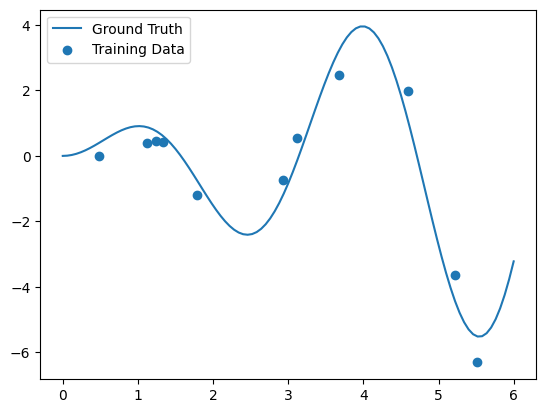

In [19]:
np.random.seed(5)
X, y = get_data(ground_truth, n_samples=11)
axis = np.linspace(0, 6, 101)

plt.plot(axis, ground_truth(axis), label='Ground Truth')
plt.scatter(X, y, label='Training Data')
plt.legend()
plt.show()

## Kernel functions

The kernel defines the *covariance structure* of the GP — it encodes our prior belief about how smooth or wiggly the unknown function should be. Implement the two kernel functions defined below.

> **Exponential Covariance** (Equation 6.63):
> $$k(\mathbf{x}_n, \mathbf{x}_m) = \theta_0 \exp\!\left(-\frac{\theta_1}{2}\|\mathbf{x}_n - \mathbf{x}_m\|^2\right) + \theta_2 + \theta_3\,\mathbf{x}_n^\top\mathbf{x}_m$$

> **Exponential Kernel** (Equation 6.56):
> $$k(x, x') = \exp(-\theta\,|x - x'|)$$

**What each parameter controls (Exponential Covariance):**

| Parameter | Role | Effect when large |
|-----------|------|-------------------|
| $\theta_0$ | overall scale | larger amplitude functions |
| $\theta_1$ | inverse length-scale | more wiggly / rapidly varying |
| $\theta_2$ | constant offset | shifts covariance up uniformly |
| $\theta_3$ | linear term weight | adds a linear trend component |

**Python note:** Both kernels are implemented as classes with `__call__`, exactly like in Exercise 1 — this allows storing hyperparameters as attributes while using the object like a function: `kernel(x1, x2)`.

In [3]:
class ExponentialCovariance:
    """Gaussian kernel from Eq. 6.63."""
    def __init__(self, theta0=1, theta1=1, theta2=0, theta3=0):
        self.theta0 = theta0
        self.theta1 = theta1
        self.theta2 = theta2
        self.theta3 = theta3

    def __call__(self, x, y):
        return self.theta0 * np.exp(-0.5 * self.theta1 * np.linalg.norm(x - y)**2) + self.theta2 + self.theta3 * x * y

kernel = ExponentialCovariance()
kernel(2, 1) # should return 0.6065306597126334

np.float64(0.6065306597126334)

In [4]:
class ExponentialKernel:
    """Exponential kernel from Eq. 6.56."""
    def __init__(self, theta=1):
        self.theta = theta

    def __call__(self, x, y):
        return np.exp(-self.theta * np.linalg.norm(x - y))
kernel = ExponentialKernel()
kernel(2, 1) # should return 0.36787944117144233

np.float64(0.36787944117144233)

In [5]:
@interact(theta=(0, 3, 0.1))
def plot(theta=1):
    point = 0
    axis = np.linspace(-3, 3, 201)

    kernel = ExponentialCovariance()
    plt.plot(axis, [kernel(0, x) for x in axis])

    kernel = ExponentialKernel(theta)
    plt.plot(axis, [kernel(0, x) for x in axis])

interactive(children=(FloatSlider(value=1.0, description='theta', max=3.0), Output()), _dom_classes=('widget-i…

Feel free to implement additional kernels from the lecture (e.g. periodic, Matérn). Any valid kernel can be plugged directly into the GP model below — just as in Exercise 1, the model code never inspects the inputs directly, only calls the kernel function.

## Prior Distribution

Before observing any data, a GP defines a **prior distribution over functions**. Any finite collection of function values $(f(x_1), \ldots, f(x_M))$ follows a multivariate Gaussian with:
- **Mean** $\boldsymbol{\mu} = \mathbf{0}$ (no prior preference for positive or negative values)
- **Covariance** $K_{ij} = k(x_i, x_j)$ — the kernel evaluated at all pairs of input points

Drawing a *prior sample* means drawing one vector from this Gaussian, then plotting it as a function. The shape of the drawn functions is entirely determined by the kernel.

> Implement the class `GaussianProcess` with the following methods:
> - `__init__`: Store the kernel function so it can be used in both `prior_samples` and `fit`/`predict`.
> - `prior_samples`: Build the covariance matrix $\mathbf{K}$ and draw `n_samples` functions from $\mathcal{N}(\mathbf{0}, \mathbf{K})$ using `np.random.multivariate_normal`.

In [6]:
class GaussianProcess:
    def __init__(self, kernel_func):
        self.kernel_func = kernel_func

    def prior_samples(self, X, n_samples):
        K = np.array([[self.kernel_func(x1, x2) for x2 in X] for x1 in X])
        return np.random.multivariate_normal(mean=np.zeros(len(X)), cov=K, size=n_samples)

> Plot five prior samples for each kernel side-by-side, similar to Figure on slide 47.

**What to look for:**
- **Exponential Covariance** ($\theta_1 = 1$): smooth, differentiable sample paths — the squared-exponential decay ensures nearby points are highly correlated.
- **Exponential Kernel** ($\theta = 1$): less smooth, kinked paths — the absolute-value distance creates continuous but non-differentiable functions.

The key insight: all these functions are drawn *before seeing any data*. The kernel alone determines the family of plausible functions.

/var/folders/_1/n85hbfgd2j93hh10__cjmgh40000gn/T/ipykernel_33444/220291162.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


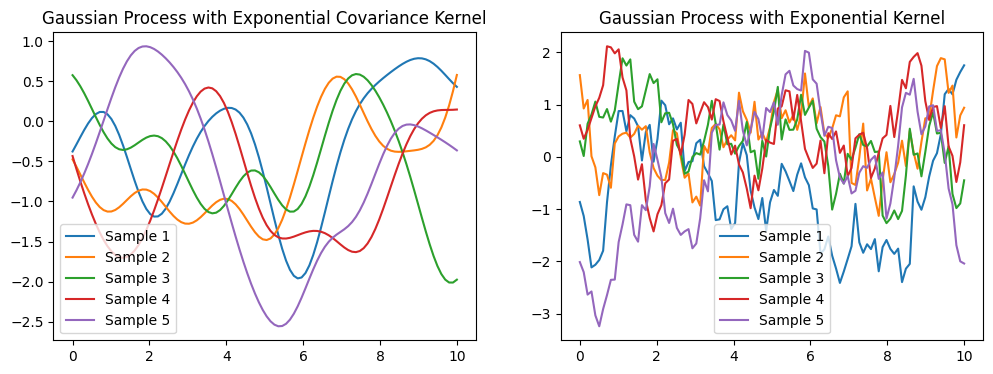

In [18]:
exp_cov_kernel = ExponentialCovariance()
gp = GaussianProcess(exp_cov_kernel)
exp_kernel = ExponentialKernel()
gp_exp = GaussianProcess(exp_kernel)
axis = np.linspace(0, 10, 100)
samples = gp.prior_samples(axis, n_samples=5)
samples_exp = gp_exp.prior_samples(axis, n_samples=5)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i in range(5):
    ax[0].plot(axis, samples[i], label=f'Sample {i+1}')
    ax[1].plot(axis, samples_exp[i], label=f'Sample {i+1}')
ax[0].set_title('Gaussian Process with Exponential Covariance Kernel')
ax[1].set_title('Gaussian Process with Exponential Kernel')
ax[0].legend()
ax[1].legend()

fig.show()

## Conditional (Predictive) Distribution

After observing data, we update the prior into a **posterior distribution over functions** — this is the GP's main prediction mechanism.

Our goal is to find the predictive distribution $p(t_{N+1} \mid \mathbf{t})$ for a new input $\mathbf{x}_{N+1}$.

### Derivation

**Step 1 — Joint distribution.** The $(N+1)$-dimensional joint distribution is:
$$p(\mathbf{t}_{N+1}) = \mathcal{N}(\mathbf{t}_{N+1} \mid \mathbf{0},\, \mathbf{C}_{N+1})$$
where the covariance includes a noise term on the diagonal:
$$C(\mathbf{x}_n, \mathbf{x}_m) = k(\mathbf{x}_n, \mathbf{x}_m) + \beta^{-1}\delta_{nm}$$
Here $\beta^{-1}$ is the noise variance — adding it to the diagonal makes $\mathbf{C}$ invertible even when $k$ is only positive semi-definite.

**Step 2 — Partition the covariance.** We split $\mathbf{C}_{N+1}$ into blocks:
$$\mathbf{C}_{N+1} = \begin{pmatrix} \mathbf{C}_N & \mathbf{k} \\ \mathbf{k}^\top & c \end{pmatrix}$$
where $\mathbf{C}_N \in \mathbb{R}^{N\times N}$ is the training covariance, $\mathbf{k} \in \mathbb{R}^N$ has entries $k(\mathbf{x}_n, \mathbf{x}_{N+1})$, and $c = k(\mathbf{x}_{N+1}, \mathbf{x}_{N+1}) + \beta^{-1}$.

**Step 3 — Condition (Section 2.3.1).** Applying Gaussian conditioning gives:
$$m(\mathbf{x}_{N+1}) = \mathbf{k}^\top \mathbf{C}_N^{-1} \mathbf{t}, \qquad \sigma^2(\mathbf{x}_{N+1}) = c - \mathbf{k}^\top \mathbf{C}_N^{-1} \mathbf{k}$$

**Symbol glossary:**
- $\mathbf{C}_N$: training covariance matrix ($N \times N$), computed once at `fit` time
- $\mathbf{k}$: kernel vector between test point and all training points ($N \times 1$)
- $c$: prior variance at the test point (includes noise)
- $m$: posterior mean prediction
- $\sigma^2$: posterior variance — shrinks to 0 near training data, grows in unexplored regions

> Implement the `fit` and `predict_conditional` methods. In `fit`, build $\mathbf{C}_N$ and pre-compute its inverse (store it to avoid recomputing for every prediction). In `predict_conditional`, compute $m$ and $\sigma^2$ for a single test point.

In [23]:
class GaussianProcess(GaussianProcess):
    def fit(self, X, y, noise=.1):
        self.X_train = X
        self.y_train = y
        self.noise = noise
        K = np.array([[self.kernel_func(x1, x2) for x2 in X] for x1 in X]) + noise**2 * np.eye(len(X))
        self.K_inv = np.linalg.inv(K)

    def predict_conditional(self, inp):
        K_s = np.array([self.kernel_func(x_train, inp) for x_train in self.X_train])
        K_ss = self.kernel_func(inp, inp) + self.noise**2
        mu_s = K_s.T @ self.K_inv @ self.y_train
        cov_s = K_ss - K_s.T @ self.K_inv @ K_s
        return mu_s, cov_s

> Plot the GP predictions alongside the training data. Use `plt.fill_between` to shade the $\pm 1$ standard deviation band (see [this example](https://stackoverflow.com/questions/45136420/filling-range-of-graph-in-matplotlib)).

**What to look for in the plot:**
- The **mean prediction** (blue line) should follow the general trend of the data.
- The **shaded band** (±1 std) should be *narrow near training points* — the GP is confident where it has seen data — and *wide in unexplored regions* (left/right of the data range). This is the unique advantage of GPs over kernel regression: free uncertainty estimates.
- The band width is controlled by `noise`: lower noise → tighter band at training points (more confident interpolation).

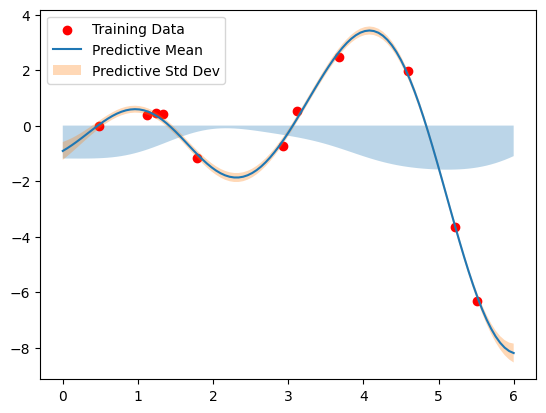

In [28]:
exp_cov_kernel = ExponentialCovariance()
gp = GaussianProcess(exp_cov_kernel)
samples = gp.prior_samples(axis, n_samples=5)
plt.fill_between(axis, samples[0], alpha=0.3)
plt.scatter(X, y, color='red', label='Training Data')
gp.fit(X, y)
preds = np.array([gp.predict_conditional(x) for x in axis])
mu_s = preds[:, 0]
std_s = np.sqrt(preds[:, 1])
plt.plot(axis, mu_s, label='Predictive Mean')
plt.fill_between(axis, mu_s - std_s, mu_s + std_s, alpha=0.3, label='Predictive Std Dev')
plt.legend()
plt.show()

> Use the interactive plot below to explore how each hyperparameter affects the GP predictions. Adapt the code if needed to match your implementation.

**Parameter cheatsheet:**

| Slider | Effect |
|--------|--------|
| `noise` | Observation noise $\beta^{-1}$: high → predictions smooth through data; low → predictions interpolate data exactly |
| `theta0` | Overall amplitude scale: higher → larger swings |
| `theta1` | Inverse length-scale: higher → more rapid variation, more wiggly predictions |
| `theta2` | Constant covariance offset: adds a global bias to all covariances |
| `theta3` | Linear kernel weight: introduces a linear trend into the prior |

**Suggested experiments:**
- Set `theta1` very small → very smooth, almost flat predictions.
- Set `noise` near 0 → the mean should pass through every training point.
- Set `theta3 > 0` with everything else at default → observe the linear trend added to predictions.

In [29]:
def plot_predict_conditional(noise=.2, theta0=1, theta1=1, theta2=0, theta3=0):
    kernel_func = ExponentialCovariance(theta0=theta0, theta1=theta1, theta2=theta2, theta3=theta3)
    gp = GaussianProcess(kernel_func)
    gp.fit(X, y, noise=noise)

    fig = plt.figure(figsize=(13, 5))
    axis = np.linspace(min(X)-2, max(X)+2, 101)

    preds = np.array([gp.predict_conditional(x) for x in axis])

    mean = preds[:, 0]
    std = np.sqrt(preds[:, 1])

    plt.plot(axis, mean, label='Predictions')
    plt.plot(axis, ground_truth(axis), label='Ground Truth')
    plt.scatter(X, y)
    plt.fill_between(axis, mean-std, mean+std, color='red', alpha=.2, label='Std')
    plt.legend(loc=2)
    plt.show()

interact(plot_predict_conditional,  noise=(0.01, 1, 1e-3), theta0=(0, 5, .1), theta1=(0, 5, .1), theta2=(0, 5, .1), theta3=(0, 5, .1))

interactive(children=(FloatSlider(value=0.2, description='noise', max=1.0, min=0.01, step=0.001), FloatSlider(…

<function __main__.plot_predict_conditional(noise=0.2, theta0=1, theta1=1, theta2=0, theta3=0)>